In [3]:
import pandas as pd
import numpy as np

For a discussion of the data, look [here.](https://archive.ics.uci.edu/dataset/186/wine+quality)



In [1]:
# Will need to use url;lib for interent load
website = ""
url = f"{website}datasets/winequality.names"
with open(url) as fh:
    text = fh.read()
print(text)

Citation Request:
  This dataset is public available for research. The details are described in [Cortez et al., 2009]. 
  Please include this citation if you plan to use this database:

  P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. 
  Modeling wine preferences by data mining from physicochemical properties.
  In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 0167-9236.

  Available at: [@Elsevier] http://dx.doi.org/10.1016/j.dss.2009.05.016
                [Pre-press (pdf)] http://www3.dsi.uminho.pt/pcortez/winequality09.pdf
                [bib] http://www3.dsi.uminho.pt/pcortez/dss09.bib

1. Title: Wine Quality 

2. Sources
   Created by: Paulo Cortez (Univ. Minho), Antonio Cerdeira, Fernando Almeida, Telmo Matos and Jose Reis (CVRVV) @ 2009
   
3. Past Usage:

  P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. 
  Modeling wine preferences by data mining from physicochemical properties.
  In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 016

In [4]:
dfs = []
# "red" -> 0, "white" -> 1
for (i,suf) in enumerate("red white".split()):
    fn  = f"datasets/winequality-{suf}.csv"
    print(fn)
    wine_df = pd.read_csv(fn,sep=";")
    quality = wine_df["quality"]
    wine_df = wine_df.iloc[:,:10]
    # Add new color col
    wine_df["color"] = i
    # Make sure  quality is the last col
    wine_df["quality"] = quality
    dfs.append(wine_df)

reds_whites = pd.concat(dfs)

datasets/winequality-red.csv
datasets/winequality-white.csv


In [5]:
reds_whites

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,color,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,0,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,0,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,0,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,0,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,1,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,1,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,1,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,1,7


In [6]:
reds_whites["quality"].unique()

array([5, 6, 7, 4, 8, 3, 9])

In [7]:
reds_whites["quality_level"] = 0
level1_b = reds_whites["quality"] == 6
level2_b = reds_whites["quality"] >= 7
reds_whites.loc[level2_b,"quality_level"] = 2
reds_whites.loc[level1_b,"quality_level"] = 1

In [8]:
reds_whites["quality_level"].unique()

array([0, 1, 2])

In [9]:
for rtg in sorted(reds_whites["quality"].unique()):
    print(f"{rtg}: {(reds_whites["quality"] == rtg).sum():>5,}")

3:    30
4:   216
5: 2,138
6: 2,836
7: 1,079
8:   193
9:     5


In [10]:
reds_whites.shape

(6497, 13)

In [11]:
reds_whites.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'color', 'quality', 'quality_level'],
      dtype='object')

##  Exercise one

Plot `acidity` versus `free sulfur dioxide` 
using a scatterplot.  Color the scatter points by `color`

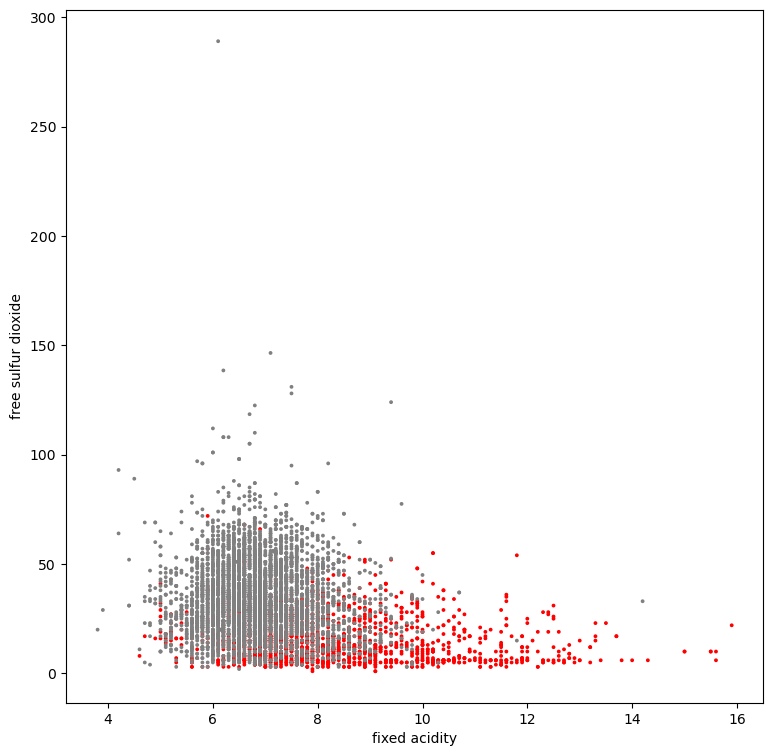

In [13]:
color_col = reds_whites["color"]
colors = np.array(["red","gray"])
_ = reds_whites.plot(x="fixed acidity",y="free sulfur dioxide",
                     kind="scatter",color=colors[color_col],
                     s=3,figsize=(9,9))

In [167]:
quality_col.min(),quality_col.max()

(3, 9)

Now color by `quality_level`:

In [192]:
reds_whites.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'color', 'quality', 'quality_level'],
      dtype='object')

In [197]:
type(trimmed_rs)

pandas.core.frame.DataFrame

In [235]:
fa_col = reds_whites.loc[:,"fixed acidity"]
sd_col = reds_whites.loc[:,"free sulfur dioxide"]
print(fa_col.min(),fa_col.max())
print(sd_col.min(),sd_col.max())

3.8 15.9
1.0 289.0


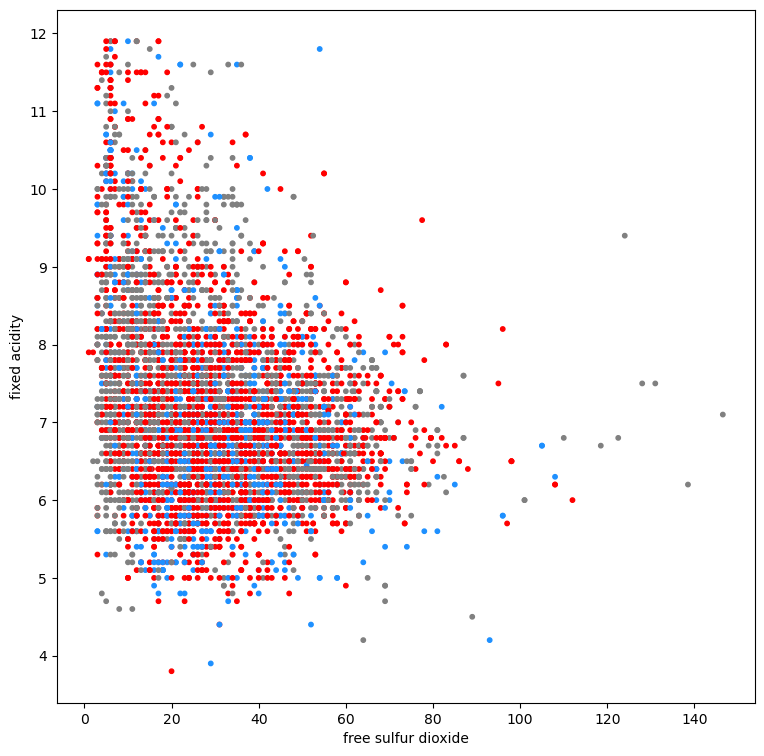

In [242]:
quality_col = reds_whites.loc[:,"quality_level"]
colors = np.array(["gray","red", "dodgerblue"])

#col1, col2 =  'citric acid',"volatile acidity"
#col2, col1 =  'density',"volatile acidity"
col1, col2 =  "fixed acidity", 'free sulfur dioxide'
trimmed_rs  = reds_whites[(reds_whites[col1] < 12) &
                          (reds_whites[col2] < 150)]
quality_col = trimmed_rs.loc[:,"quality_level"]
_ = trimmed_rs.plot(x=col2,y=col1,
                     kind="scatter",color=colors[quality_col],
                     s=10,figsize=(9,9))

##  Exercise Two
Do a hexbin plot of the same variables.  But first use the picture from Exercise One to trim off outliers -- extreme values -- from both variables,
so as to achieve a more compact more interpretable picture.

Look at an example of a hexbin plot [here.](https://matplotlib.org/stable/gallery/statistics/hexbin_demo.html)

In [222]:
trimmed_b = (reds_whites["fixed acidity"] < 10) & (reds_whites["free sulfur dioxide"] < 80)
trimmed = reds_whites[trimmed_b]

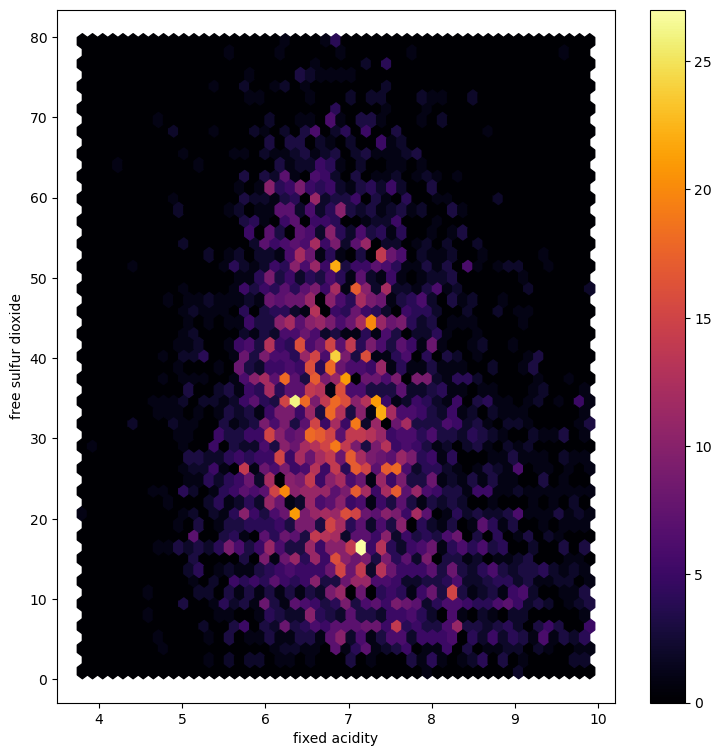

In [223]:
_ = trimmed.plot(x="fixed acidity",y="free sulfur dioxide",
                     kind="hexbin",gridsize=50, cmap='inferno', figsize=(9,9))

##  Exercise Three

Do a plot with 4 subplots

```python
from matplotlib import pyplot as plt
(fg, ax_grid) = plt.subplots(2,2,figsize=(9,9))
axes = (ax_grid[0,0],ax_grid[0,1],ax_grid[1,0],ax_grid[1,1])
```

Each subplot should do a scatterplot of one pair of variables 
from `df`

```python
df.plot(.... ax=axes[i])
```

Here are the four variable pairs your figure should scatterplot:

```python
(("fixed acidity","free sulfur dioxide"),("fixed acidity","citric acid"),
 ("fixed acidity","residual sugar"),("fixed acidity", "sulphates"))
```

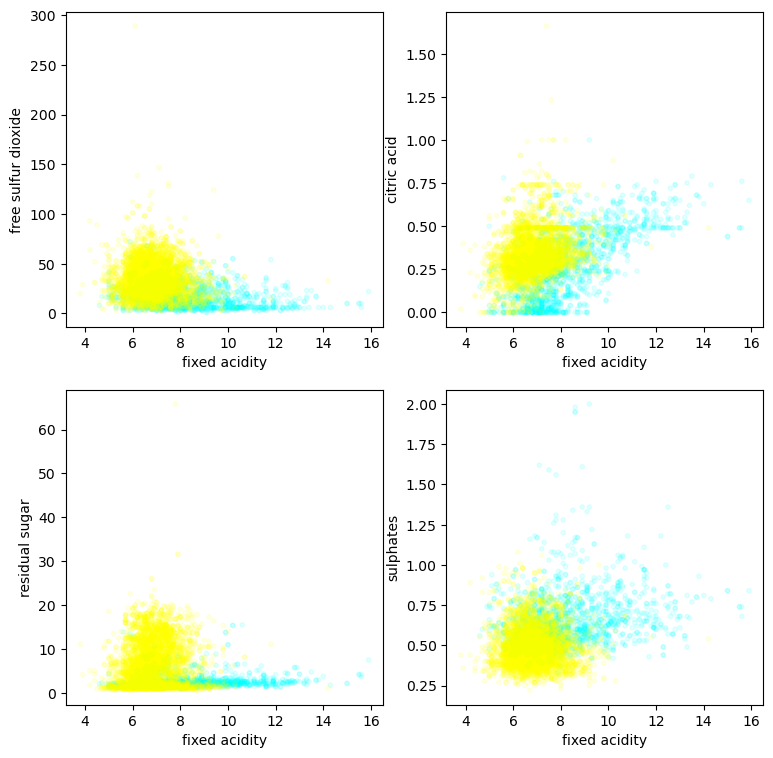

In [19]:
from matplotlib import pyplot as plt

var_pairs = (("fixed acidity","free sulfur dioxide"),("fixed acidity","citric acid"),
             ("fixed acidity","residual sugar"),("fixed acidity", "sulphates"))

(fg, ax_grid) = plt.subplots(2,2,figsize=(9,9))
axes = (ax_grid[0,0],ax_grid[0,1],ax_grid[1,0],ax_grid[1,1])

colors = np.array(["aqua", "yellow"])
for (i,(x,y)) in  enumerate(var_pairs):
        reds_whites.plot(x=x,y=y, kind="scatter", s=10, color=colors[color_col],ax=axes[i],alpha=.1)

Do another plot which plots the same two variables but plots the red and white points on two different
axes placed side by side.  Pay attention to the numerical values on the x and y axes and try to make
the two plots easily comparable.

The two plots are not comparable.

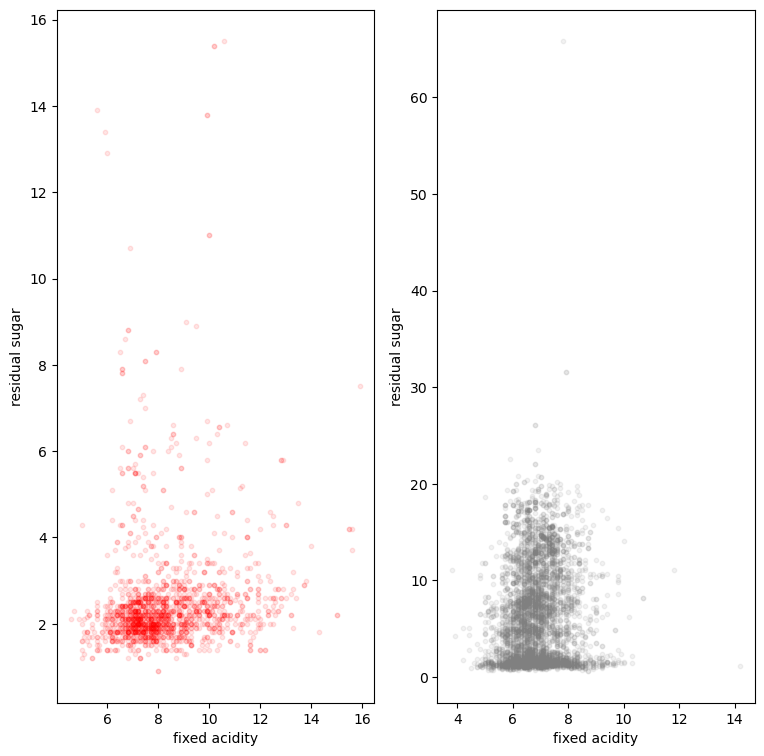

In [26]:
from matplotlib import pyplot as plt

(fg, (ax0,ax1)) = plt.subplots(1,2,figsize=(9,9))#,sharex=True,sharey=True)
axes = (ax0,ax1)
colors = np.array(["red", "gray"])
for i in  range(2):
    if i == 0:
        col = "red"
    else:
        col= "white"
    samps = reds_whites[reds_whites["color"] == i]
    col = colors[i]
    colors[color_col]
    samps.plot(x="fixed acidity",y="residual sugar", kind="scatter", s=10, color=col,ax=axes[i],alpha=.1)

##  Exercise Four

Is it true that no wine with a quality rating > 7
has a fixed acidity level greater than 10?

Write one expression that verifies or disconfirms this claim.
If the statement is not true, show the examples that disprove it.

In [132]:
quality = reds_whites["quality"]
fixed_acidity = reds_whites["fixed acidity"]

In [163]:
q_bound,fa_bound = 7, 10
(~((quality > q_bound) & (fixed_acidity > fa_bound))).all()

np.False_

The statement is not true.  However, it is almost true.

There are exactly 5 wine samples out of nearly 6500 that are counter-examples.
All 5 have quality rating 8.

In [135]:
reds_whites.shape

(6497, 12)

In [164]:
reds_whites[((quality > q_bound) & (fixed_acidity > fa_bound))]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,color,quality
278,10.3,0.32,0.45,6.4,0.073,5.0,13.0,0.9976,3.23,0.82,0,8
440,12.6,0.31,0.72,2.2,0.072,6.0,29.0,0.9987,2.88,0.82,0,8
455,11.3,0.62,0.67,5.2,0.086,6.0,19.0,0.9988,3.22,0.69,0,8
495,10.7,0.35,0.53,2.6,0.070,5.0,16.0,0.9972,3.15,0.65,0,8
498,10.7,0.35,0.53,2.6,0.070,5.0,16.0,0.9972,3.15,0.65,0,8


##  Exercise Five

Do a histogram of the density values of the data set.  Trim off density outliers.
And get help at setting the threshholds by first doing a kde plot.

In [156]:
density = reds_whites["density"]
print(density.min(),density.max())

0.98711 1.03898


<Axes: ylabel='Frequency'>

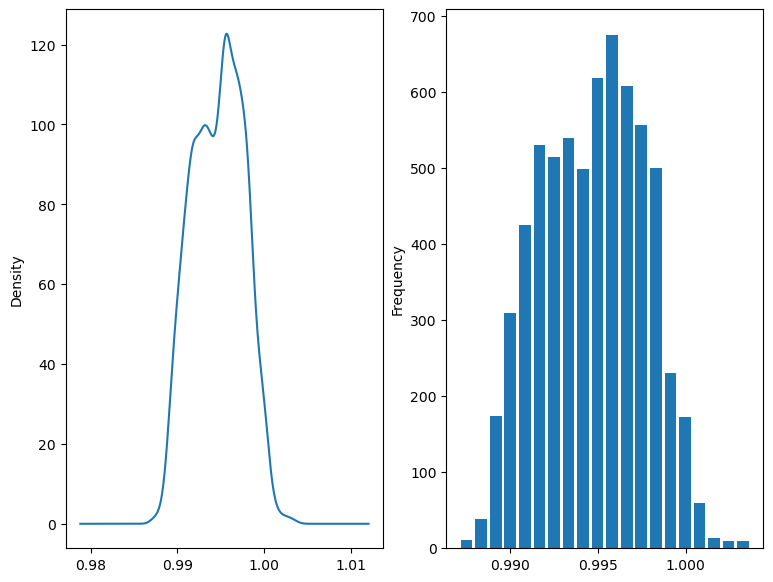

In [160]:
(fg, (ax0,ax1)) = plt.subplots(1,2,figsize=(9,7))

density = reds_whites["density"]

trimmed_d.plot(kind="kde",ax=ax0)
trimmed_d_b = (density > .987) & (density < 1.004) 
trimmed_d =  density[trimmed_d_b]
trimmed_d.plot(kind="hist",bins=20,rwidth=.8,ax=ax1)

In [52]:
(~(target[df["magnesium"] > 120] == 2)).all()

np.False_

##  Exercise Six

What percentage of the white wine samples have fixed acidity greater than 10?

Soln 1

In [246]:
color_col.unique()

array([0, 1])

In [247]:
color_col = reds_whites["color"]  
# color = 1 in the color col is white
n2 = (color_col==1).sum()
n2

np.int64(4898)

In [256]:
reds_whites['fixed acidity'].max()

15.9

In [257]:
n1 = ((color_col==1) & (reds_whites['fixed acidity'] > 10)).sum()

In [258]:
n1/n2

np.float64(0.0014291547570436914)